In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os

chemin_racine = os.path.abspath('..')

if chemin_racine not in sys.path:
    sys.path.append(chemin_racine)

# 1. Analyse Exploratoire des Données

__Objectif Métier :__ Analyser le profil financier des emprunteurs afin de préparer les données pour un modèle de Credit Scoring (Prédiction de la Probabilité de Défaut).

__Jeu de données :__ [Give Me Some Credit de Kaggle](https://www.kaggle.com/competitions/GiveMeSomeCredit/data)

Ici, il s'agit essentiellement d'une première prise en main des données, puis du nettoyage de celles-ci (traitement des données aberrantes, manquantes...), nous pourrons ensuite observer leur distribution avant de passer au Feature engineering.

## a. Imports et premières observations
Dans un premier temps, on importe les bibliothèques utiles et le jeu de données et on assigne nos données à des variables.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

description_donnees = pd.read_excel("../data/raw/Data Dictionary.xls", index_col=1)
description_donnees

,Unnamed: 0,Unnamed: 2
Description,Variable Name,Type
Person experienced 90 days past due delinquency or worse,SeriousDlqin2yrs,Y/N
Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits,RevolvingUtilizationOfUnsecuredLines,percentage
Age of borrower in years,age,integer
Number of times borrower has been 30-59 days past due but no worse in the last 2 years.,NumberOfTime30-59DaysPastDueNotWorse,integer
"Monthly debt payments, alimony,living costs divided by monthy gross income",DebtRatio,percentage
Monthly income,MonthlyIncome,real
Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards),NumberOfOpenCreditLinesAndLoans,integer
Number of times borrower has been 90 days or more past due.,NumberOfTimes90DaysLate,integer
Number of mortgage and real estate loans including home equity lines of credit,NumberRealEstateLoansOrLines,integer


On comprend que la variable que l'on cherche à prédire dans notre étude sera la variabe ```SeriousDlqin2yrs``` puisqu'on voit dans sa description "Person experienced 90 days past due delinquency or worse" ce qui correspond justement à la réponse de la question à laquelle on cherche à répondre : "Si je prête de l'argent à cette personne aujourd'hui, a-t-elle de fortes chances de cesser de me rembourser dans les 24 prochains mois ?"

In [4]:
credit_data = pd.read_csv("../data/raw/cs-training.csv", index_col=0, header=0)

In [5]:
test_credit_data = pd.read_csv("../data/raw/cs-test.csv", index_col=0, header=0)
test_credit_data.head() # Le fait que "SeriousDlqin2yrs"	soit en NaN dans la data de test confirme la conclusion précédente

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


### Déséquilibre de la classe `SeriousDlqin2yrs`

Nous voulons quantifier le déséquilibre entre les négatifs et positifs de notre classe cible pour que celui-ci se reflète dans notre split de nos données d'entrainement et de validation de notre modèle.

In [6]:
counts_serious_dlq = credit_data["SeriousDlqin2yrs"].value_counts(normalize=True)
ratio_serious_dlq =  float(counts_serious_dlq[0]/counts_serious_dlq[1])
print(counts_serious_dlq, '\n', ratio_serious_dlq)


SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64 
 13.961101137043688


On a donc un ratio d'environs 14 bons payeurs pour 1 mauvais payeur, cette statistique nous donne de bonnes indications, notamment comment nous allons agencer notre train test split (avec stratify) et quelles métriques nous alons utiliser pour mesurer notre modèle. Pour notre split, la norme étant d'avoir au minimum 1000 à 2000 individus à défaut de paiement dans le set de test, avec un tel ratio, il faut que l'échantillon de test soit à $1000-2000 \times 15 = 15 000-30 000$ soit environs $10-20\%$ du dataset complet. On prend la fourchette haute de $20\%$

In [7]:
from sklearn.model_selection import train_test_split

train_credit_data, val_credit_data = train_test_split(credit_data, test_size=0.2, random_state=67, stratify=credit_data["SeriousDlqin2yrs"])
train_credit_data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
49298,0,0.000000,48,0,0.222274,4300.0,7,0,0,0,2.0
137460,0,0.332408,66,1,0.284009,9967.0,5,0,1,0,0.0
69957,0,0.135041,57,0,0.014171,17500.0,6,0,0,0,0.0
40035,0,0.386886,54,0,0.307586,12350.0,15,0,2,0,2.0
12640,0,0.404259,47,0,0.450497,6736.0,6,0,2,0,2.0


## b. Traitement des Données Manquantes
La prochaine étape de notre étude va être de déterminer les variables qui comportent des données manquantes, on va ensuite discuter des hypothèses potentielles de ces manques et de comment nous allons les traiter.

In [8]:
train_credit_data.info()

<class 'pandas.DataFrame'>
Index: 120000 entries, 49298 to 36446
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      120000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  120000 non-null  float64
 2   age                                   120000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  120000 non-null  int64  
 4   DebtRatio                             120000 non-null  float64
 5   MonthlyIncome                         96258 non-null   float64
 6   NumberOfOpenCreditLinesAndLoans       120000 non-null  int64  
 7   NumberOfTimes90DaysLate               120000 non-null  int64  
 8   NumberRealEstateLoansOrLines          120000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  120000 non-null  int64  
 10  NumberOfDependents                    116853 non-null  float64
dtypes: float64(4)

In [9]:
compteur_nan = train_credit_data.isna().mean()
print(compteur_nan.sort_values(ascending=False)*100)


MonthlyIncome                           19.7850
NumberOfDependents                       2.6225
SeriousDlqin2yrs                         0.0000
age                                      0.0000
RevolvingUtilizationOfUnsecuredLines     0.0000
DebtRatio                                0.0000
NumberOfTime30-59DaysPastDueNotWorse     0.0000
NumberOfOpenCreditLinesAndLoans          0.0000
NumberOfTimes90DaysLate                  0.0000
NumberRealEstateLoansOrLines             0.0000
NumberOfTime60-89DaysPastDueNotWorse     0.0000
dtype: float64


On tire plusieurs informations de notre appel à la méthode info() :
- On a un total de 120000 profils clients dans les données d'entraînement
- Parmi les variables, ```MonthlyIncome``` et ```NumberOfDependents``` sont celles qui présentent des données manquantes
    - Pour ```MonthlyIncome``` : On a 19.8% de valeurs manquantes
    - Pour ```NumberOfDependents``` : on a 2.6% de valeurs manquantes

 ## i. Variable : ```MonthlyIncome```
   - __Hypothèse :__ Ici, on peut deviner plusieurs raisons potentielles qui auraient poussé un client à laisser cette case vide :
       - Complexité : Le revenu du client est complexe et ne se résume pas en un monthly income
       - Précarité : c'est un revenu faible, le client ayant peur que cette statistique lui fasse défaut, il la cache
       - Irrégularité : son revenu mensuel est très volatile et le client ne sait pas quoi mettre
   - __Nature Statistique :__ Puisqu'on a pu identifier de nombreuses raisons potentielles d'omission volontaire, on conjecture que cette variable est de type MNAR (Missing not at random)
   - __Stratégie de traitement et validation :__ On va choisir d'utiliser une méthode d'imputation couplée à un indicateur binaire, ainsi, on peut à la fois combler le manque pour notre régression logistique et prendre en compte l'origine comportementale du trou. La distribution des revenus étant fortement étalée vers la droite, choisit la médiane comme stratégie étant donné la sensibilité de la moyenne aux valeurs extrêmes.

 ## ii. Variable : ```NumberOfDependents```
 - __Hypothèse :__ Cette variable indique le nombre de personnes à charge. On suppose qu'ici, une missing value peut être due au fait que le client suppose que laisser la case vide lors du remplissage est un 0 explicite.
 - __Nature Statistique :__ Ici aussi, on a probablement un cas de MNAR.
 - __Stratégie de traitement et validation :__ Si l'hypothèse est avérée, on va faire le choix de remplacer les NaN par des 0. Pour valider l'hypothèse, on va essayer de voir si $$\mathbb{P}(\text{SeriousDlqin2yrs}=1 \mid \text{NumberOfDependents}=\text{NaN}) \approx \mathbb{P}(\text{SeriousDlqin2yrs}=1 \mid \text{NumberOfDependents}=0)$$


### Validation de l'hypothèse pour ```NumberOfDependents```
On pose $P_1 = \mathbb{P}(\text{SeriousDlqin2yrs}=1 \mid \text{NumberOfDependents}=\text{NaN})$ et $P_2 =\mathbb{P}(\text{SeriousDlqin2yrs}=1 \mid \text{NumberOfDependents}=0)$

In [10]:
masque = train_credit_data["NumberOfDependents"].isna()
train_data_nod_na = train_credit_data.loc[masque]

p_1 = train_data_nod_na["SeriousDlqin2yrs"].mean()

train_data_nod_0 = train_credit_data.loc[train_credit_data["NumberOfDependents"] == 0]
p_2 = train_data_nod_0["SeriousDlqin2yrs"].mean()

print(f'P_1 = {p_1}\nP_2 = {p_2}\n|P_1 - P_2| = {abs(p_1-p_2)*100}')


P_1 = 0.04512233873530346
P_2 = 0.059037722542853444
|P_1 - P_2| = 1.3915383807549981


On trouve au final que $| P_1 - P_2 | \approx 1.4 \%$, on a donc un écart assez faible pour valider notre conjecture initiale pour cette variable, on va donc appliquer la stratégie de traitement qui va être de remplacer les NaN par des 0.

In [11]:
train_credit_data["NumberOfDependents"] = train_credit_data["NumberOfDependents"].fillna(0)
train_credit_data.info()

<class 'pandas.DataFrame'>
Index: 120000 entries, 49298 to 36446
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      120000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  120000 non-null  float64
 2   age                                   120000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  120000 non-null  int64  
 4   DebtRatio                             120000 non-null  float64
 5   MonthlyIncome                         96258 non-null   float64
 6   NumberOfOpenCreditLinesAndLoans       120000 non-null  int64  
 7   NumberOfTimes90DaysLate               120000 non-null  int64  
 8   NumberRealEstateLoansOrLines          120000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  120000 non-null  int64  
 10  NumberOfDependents                    120000 non-null  float64
dtypes: float64(4)

### Mise en place de la stratégie d'imputation pour ```MonthlyIncome```
On fait le choix d'utiliser l'outil ```SimpleImputer``` de Scikit-learn. On fixe ```strategy = 'median'``` et ```add_indicator = True```.

In [12]:
from sklearn.impute import SimpleImputer

imputer_income = SimpleImputer(strategy="median",add_indicator=True)
new_income = imputer_income.fit_transform(train_credit_data[["MonthlyIncome"]])

train_credit_data["MonthlyIncome"] = new_income[:,0]
train_credit_data["MissingIncomeFlag"] = new_income[:,1]

train_credit_data.info() #Plus aucune missing value
train_credit_data["MonthlyIncome"].describe()

<class 'pandas.DataFrame'>
Index: 120000 entries, 49298 to 36446
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      120000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  120000 non-null  float64
 2   age                                   120000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  120000 non-null  int64  
 4   DebtRatio                             120000 non-null  float64
 5   MonthlyIncome                         120000 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       120000 non-null  int64  
 7   NumberOfTimes90DaysLate               120000 non-null  int64  
 8   NumberRealEstateLoansOrLines          120000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  120000 non-null  int64  
 10  NumberOfDependents                    120000 non-null  float64
 11  MissingIncome

count    1.200000e+05
mean     6.415495e+03
std      1.259368e+04
min      0.000000e+00
25%      3.916000e+03
50%      5.400000e+03
75%      7.413000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

On conclut qu'il n'y a plus aucune valeur manquante dans notre dataset, on peut donc passer au traitement des valeurs extrêmes.

## c. Traitement des Outliers
Ici, le but va être de repérer les valeurs aberrantes dans le jeu de données puis d'en analyser les causes possibles. Selon les conclusions, nous choisirons une méthode adaptée pour les lisser

In [13]:
train_credit_data.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MissingIncomeFlag
count,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,1.200000e+05,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.00000
mean,0.066842,6.424469,52.310750,0.415658,352.397293,6.415495e+03,8.451825,0.259200,1.018733,0.233592,0.739675,0.19785
std,0.249749,265.682145,14.757199,4.115098,2181.032962,1.259368e+04,5.139783,4.090316,1.132457,4.076217,1.111200,0.39838
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.000000,0.029849,41.000000,0.000000,0.175078,3.916000e+03,5.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,0.000000,0.153913,52.000000,0.000000,0.366993,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000,0.00000
75%,0.000000,0.560593,63.000000,0.000000,0.866789,7.413000e+03,11.000000,0.000000,2.000000,0.000000,1.000000,0.00000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000,1.00000


In [14]:
cols_anomalie = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "age"
]

for col in cols_anomalie:
    print(train_credit_data[col].value_counts().sort_index())

NumberOfTime30-59DaysPastDueNotWorse
0     100753
1      12836
2       3733
3       1395
4        603
5        272
6        122
7         46
8         21
9          6
10         4
12         2
96         3
98       204
Name: count, dtype: int64
NumberOfTime60-89DaysPastDueNotWorse
0     113926
1       4594
2        887
3        255
4         81
5         25
6         13
7          9
8          1
9          1
11         1
96         3
98       204
Name: count, dtype: int64
NumberOfTimes90DaysLate
0     113322
1       4199
2       1263
3        536
4        231
5         95
6         70
7         27
8         16
9         17
10         7
11         2
12         2
13         2
14         2
15         1
17         1
96         3
98       204
Name: count, dtype: int64
age
0        1
21     148
22     338
23     524
24     642
      ... 
101      3
102      3
103      1
105      1
109      1
Name: count, Length: 85, dtype: int64


L'appel à la méthode .describe() montre trois anomalies dans la distribution de nos variables et qui ont donc besoin d'un traitement spécifique :

1. Variable `age` :
    - __Observation :__ L'âge minimum relevé dans la base est de 0 an. Après un unique count, on remarque que c'est un unique cas isolé et que le reste des âges commence à 21, sûrement l'âge légal pour contracter un crédit aux États-Unis
    - __Analyse :__ C'est évidemment impossible autant biologiquement que légalement. C'est sûrement une erreur de frappe ou d'une valeur de remplacement par défaut d'un ancien système (pour éviter les NaN par ex).
    - __Décision :__ On va remplacer la ligne par la médiane pour ne pas en perdre l'information.


2. Variable ``MonthlyIncome``
    - __Observation :__ La valeur maximale atteint 3 000 000, ce qui est totalement déconnecté du 3e quartile (75 %) qui reste dans des chiffres raisonnables (7400 environs).
    - __Analyse :__ Cette valeur peut correspondre soit à un profil très riche (risque très faible), soit à une erreur de remplissage où le client a mis son revenu ou son patrimoine annuel au lieu de son revenu mensuel.
    - __Décision :__ On va faire le choix de plafonner cette variable pour éviter de biaiser notre régression.


3. Variables de retards de paiement (```NumberOfTime...```)
    - __Observation :__ Les variables mesurant le nombre de fois où un client a été en retard (30-59Days, 60-89Days, 90DaysLate) ont des maximums aberrants systématiquement plafonnés à 98, très éloignés du 75e centile. Après un affichage des "unique counts" de chacune de ces variables, on observe que les deux valeurs aberrantes qui reviennent systématiquement sont 98 et 96.
    - __Analyse :__ Mathématiquement et financièrement, accumuler 98 fois un retard de 90 jours est impossible (la banque aurait saisi les biens bien avant). Après recherche, en particulier dans les forums de Kaggle (notamment dans [cette discussion](https://www.kaggle.com/competitions/GiveMeSomeCredit/discussion/867)), de nombreux utilisateurs ont relevé ces valeurs. Le consensus est qu'il s'agit de codes internes aux sources de ces données, ce ne sont donc pas des valeurs numériques à prendre dans leur sens littéral, mais plutôt des valeurs qui ont des "sens cachés". Une observation intéressante est que le nombre de 98 est systématiquement identique pour chacun des intervalles de retard (exactement 204), pareil pour 96 (exactement 3).
    - __Décision :__ Une des méthodes les plus précises serait de faire un modèle dédié au profiling des personnes qui ont ce 98 (ou 96), mais c'est trop complexe pour cette étape. On va donc évaluer leur proportion dans le dataset pour déterminer la méthode la plus adaptée (les exclure ou les écraser).

### Traîtement de l'âge :

C'est une valeur unique, on va simplement la remplacer par la médiane des âges.

In [15]:
age_median = train_credit_data["age"].median()
train_credit_data.loc[train_credit_data["age"]== 0, "age"] = age_median
train_credit_data["age"].value_counts().sort_index()

age
21     148
22     338
23     524
24     642
25     749
      ... 
101      3
102      3
103      1
105      1
109      1
Name: count, Length: 84, dtype: int64

### Traitement des extrêmes en `MonthlyIncome`

Pour éviter que les valeurs extrêmes de cette variable ne biaisent trop nos modèles, en particulier la régression logistique, on fait le choix de les capper à un centile inférieur, que l'on va déterminer en cherchant le point d'inflexion de l'écart entre les quantiles supérieurs.

In [16]:
from src.utils import etude_sauts_quantiles, cap_outliers_quantile

print(etude_sauts_quantiles(train_credit_data, "MonthlyIncome"))

          quantile         diff
0.900    10800.000          NaN
0.910    11166.000      366.000
0.920    11667.000      501.000
0.930    12166.000      499.000
0.940    12758.120      592.120
0.950    13531.100      772.980
0.960    14607.040     1075.940
0.970    16000.000     1392.960
0.980    18000.000     2000.000
0.990    23200.000     5200.000
0.995    31205.175     8005.175
0.996    35000.000     3794.825
0.997    40150.048     5150.048
0.998    50539.522    10389.474
0.999    72000.000    21460.478
1.000  3008750.000  2936750.000


On observe que le point d'inflexion se situe entre le quantile 0.999 et le maximum absolu. On fait donc le choix de capper les valeurs extrêmes à la valeur du quantile 0.999 qui est de ``72000``, ce qui reste une valeur plausible contrairement à l'extrême qui donne un saut de presque 3 millions. Un tel salaire mensuel parait peu probable, on peut imaginer que c'est une erreur de saisie (salaire annuel, patrimoine total...).

In [17]:
train_credit_data = cap_outliers_quantile(train_credit_data, "MonthlyIncome", 0.999)
train_credit_data["MonthlyIncome"].describe()


MonthlyIncome : Plafonné au quantile 0.999 (Valeur max = 72000.00)


count    120000.000000
mean       6304.350475
std        4957.299057
min           0.000000
25%        3916.000000
50%        5400.000000
75%        7413.000000
max       72000.000000
Name: MonthlyIncome, dtype: float64

Avec cette modification, on observe que l'écart-type pour cette variable passe de ~12000 à ~4900, on voit donc bien que cette minorité de valeurs extrêmes avait une influence importante sur la dispersion des données, ce qui aurait pu fortement biaiser toute régression.

### Traîtement des variables de retard de paiement

Précédemment, on a vu que pour les trois variables `NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse` et `NumberOfTimes90DaysLate`, il y avait exactement 204 clients à 98 et 3 à 96. On cherche d'abord à savoir si ce sont les mêmes personnes ou si l'intersection entre ces groupes est vide.

In [18]:
retard = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
    ]
masque_code = train_credit_data["NumberOfTimes90DaysLate"].isin([98,96])
retards_90 = train_credit_data.loc[masque_code]
retards_90[retard].value_counts().sort_index()



NumberOfTime30-59DaysPastDueNotWorse  NumberOfTime60-89DaysPastDueNotWorse  NumberOfTimes90DaysLate
96                                    96                                    96                           3
98                                    98                                    98                         204
Name: count, dtype: int64

On conclut que ce sont les mêmes profils clients qui affichent les codes 96 et 98 pour les trois variables. Ce nombre étant marginal (environs 0.2% de l'échantillon), on fait le choix de supprimer les clients affectés.

In [19]:
train_credit_data = train_credit_data.loc[~masque_code]
train_credit_data.shape

(119793, 12)

On a correctement supprimé les anomalies, le dataset est réduit à 149 731 lignes au lieu de 150 000.

## d. Analyse bivariée conditionnelle
Ici, nous allons observer le comportement des variables explicatives en fonction de la variable cible (`SeriousDlqin2yrs`) en utilisant la bibliothèque `seaborn`.

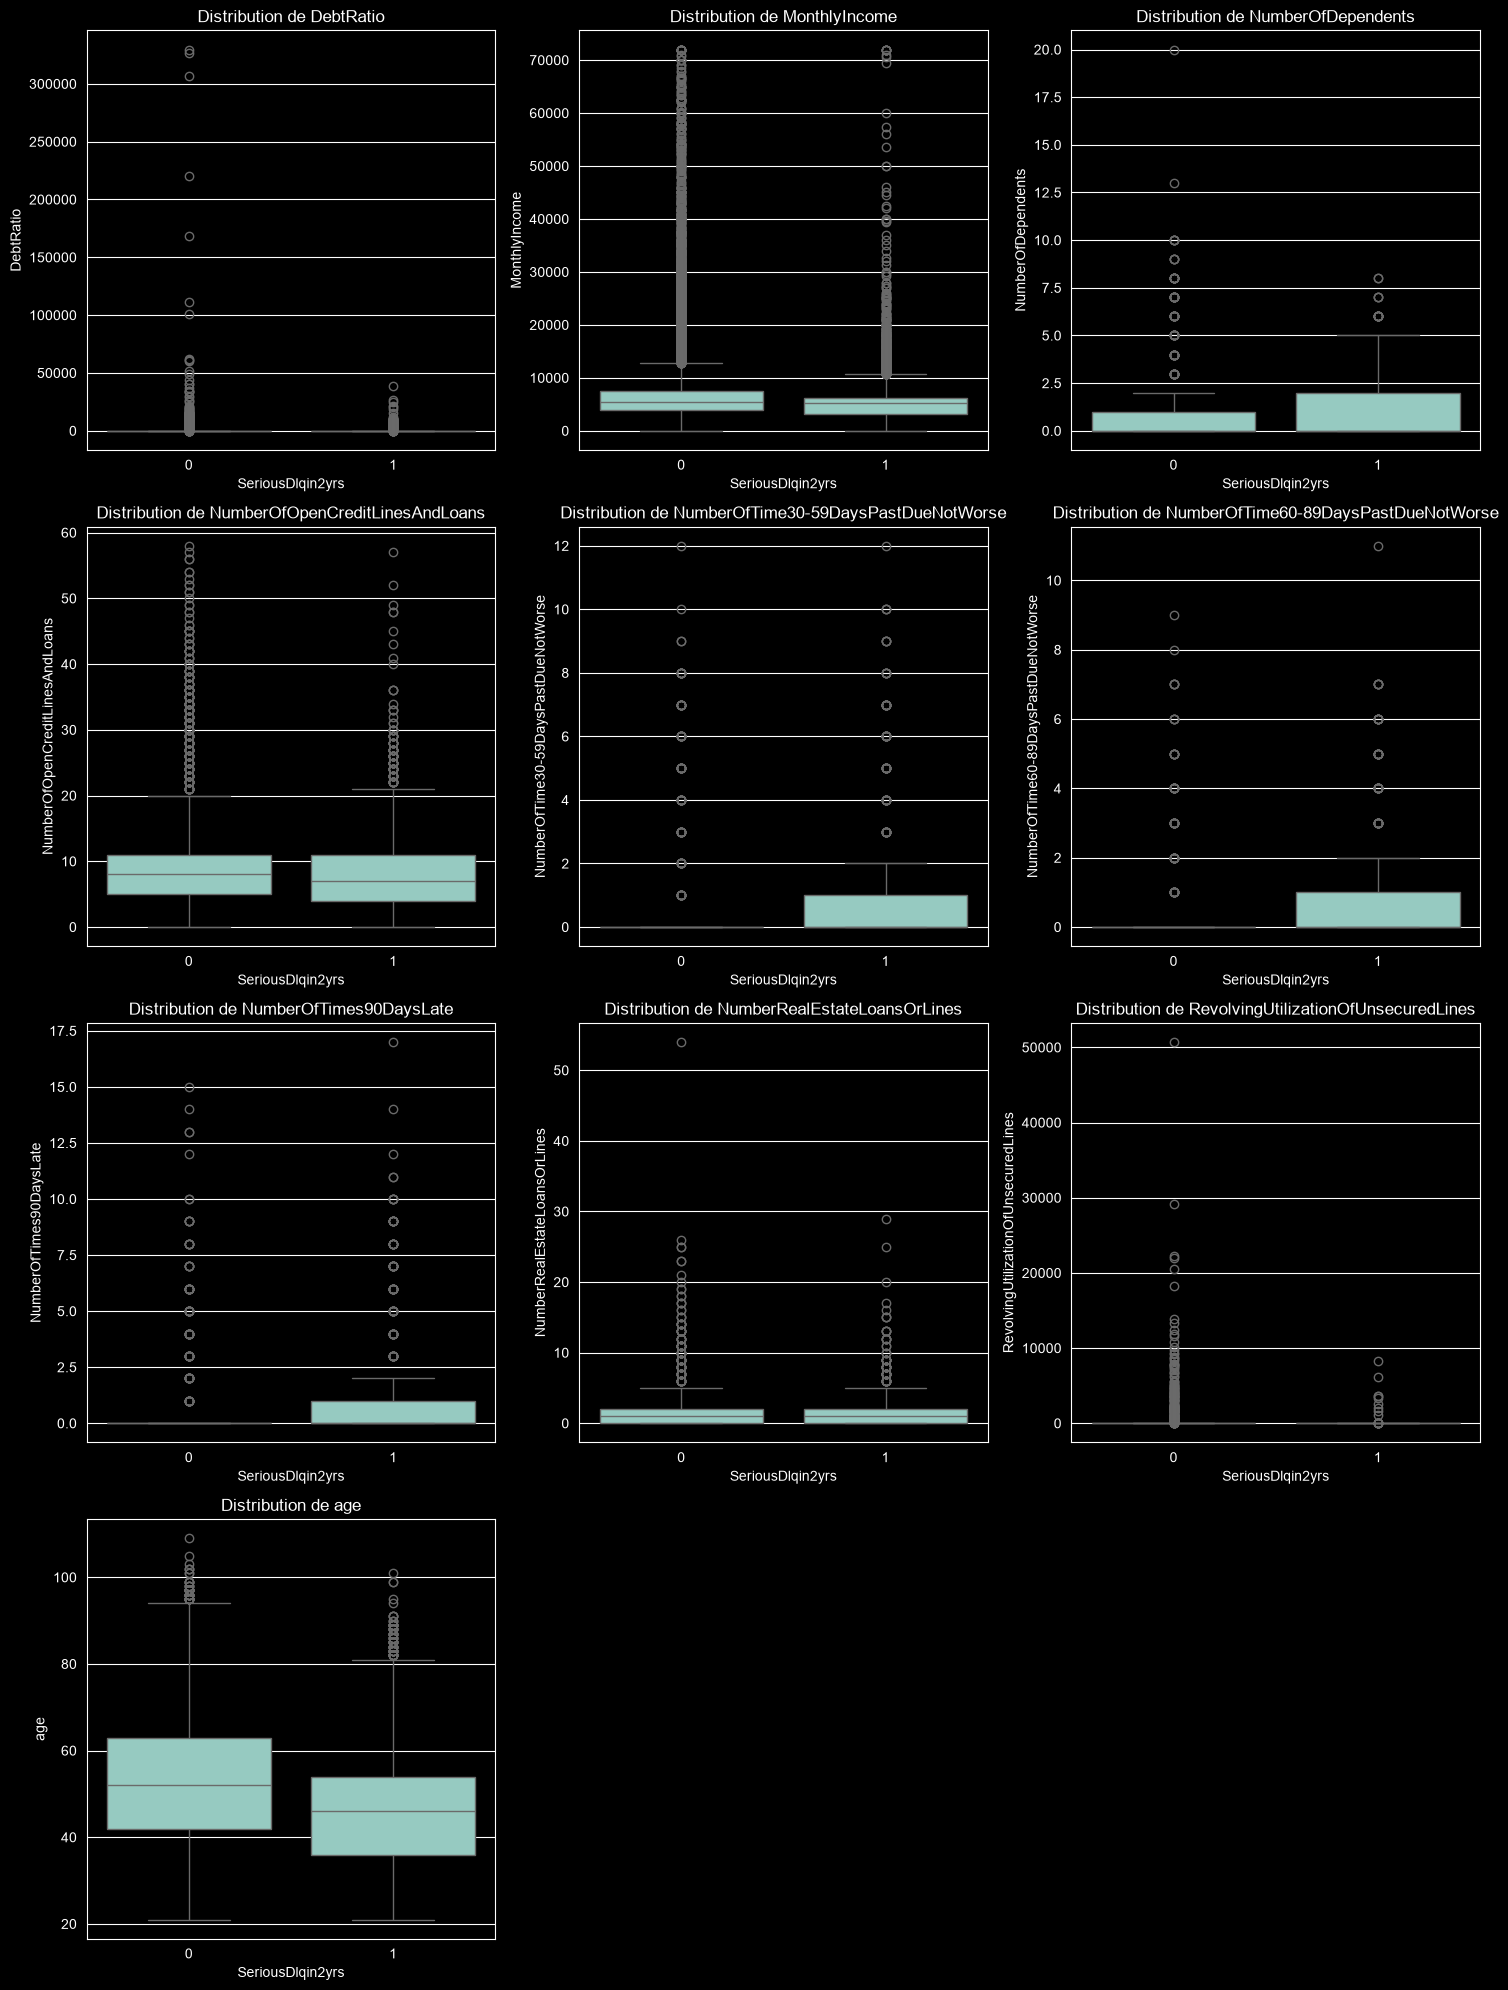

In [20]:
import seaborn as sns
import math
NCOLS = 3

tags_var_etude = train_credit_data.columns.difference(["SeriousDlqin2yrs", "MissingIncomeFlag"])
y_etude = train_credit_data["SeriousDlqin2yrs"]

nrows = math.ceil(len(tags_var_etude)/NCOLS)
fig, axes = plt.subplots(nrows=nrows, ncols=NCOLS, figsize=(15, 5 * nrows))
axes_flat = axes.flatten()

for i, col in enumerate(tags_var_etude):
    sns.boxplot(x=y_etude, y=col, data=train_credit_data, ax=axes_flat[i])
    axes_flat[i].set_title(f'Distribution de {col}')

for j in range(len(tags_var_etude),len(axes_flat)):
    axes_flat[j].set_axis_off()

plt.tight_layout()
plt.show()

### Traitement de ``RevolvingUtilizationOfUnsecuredLines``

On constate de nombreuses anomalies pour la variable `RevolvingUtilizationOfUnsecuredLines` (ratios à + de 10000), on commence donc par étudier ce cas et le traiter de manière similaire au traitement fait précédemment pour la variable `MonthlyIncome`.

In [21]:
print(etude_sauts_quantiles(train_credit_data,"RevolvingUtilizationOfUnsecuredLines"))

           quantile          diff
0.900      0.978946           NaN
0.910      0.999384      0.020439
0.920      1.000000      0.000616
0.930      1.000000      0.000000
0.940      1.000000      0.000000
0.950      1.000000      0.000000
0.960      1.000000      0.000000
0.970      1.000000      0.000000
0.980      1.006967      0.006967
0.990      1.093921      0.086954
0.995      1.376182      0.282261
0.996      1.528063      0.151882
0.997      1.824189      0.296126
0.998      3.275800      1.451610
0.999   1632.120000   1628.844200
1.000  50708.000000  49075.880000


On voit très clairement que le saut se fait dès le quantile 0.999, on applique donc le clip ici.

RevolvingUtilizationOfUnsecuredLines : Plafonné au quantile 0.998 (Valeur max = 3.28)


<Axes: xlabel='SeriousDlqin2yrs', ylabel='RevolvingUtilizationOfUnsecuredLines'>

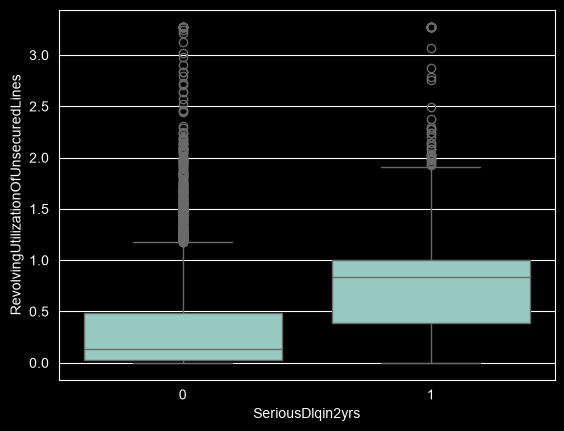

In [22]:
train_credit_data = cap_outliers_quantile(train_credit_data, "RevolvingUtilizationOfUnsecuredLines", 0.998)

sns.boxplot(x=y_etude, y="RevolvingUtilizationOfUnsecuredLines", data=train_credit_data)

On observe un résultat plus sain et cohérent avec la réalité financière avec une distinction claire entre le comportement des bons payeurs et des mauvais payeurs, avec des médianes respectivement à environs 0.15 et 0.85.

### Traitement de la variable `DebtRatio`

Pour cette variable-ci qui est censé représenter un ratio entre dettes mensuelles et revenus mensuels, on observe des valeurs aberrantes, certaines allant jusqu'à 300 000. Notre hypothèse initiale est que ces valeurs extrêmes proviennent de plusieurs sources :
- L'erreur de saisie : Comme toute valeur aberrante, on peut imaginer que l'utilisateur s'est trompé lors de la compréhension de ce qui était nécessaire à saisir pour cette variable.
- Les revenus manquants : On peut imaginer que pour les profils sur lesquels les revenus mensuels étaient manquants (NaN), puisqu'il n'est pas possible de diviser par 0, on a simplement pris la valeur brute de la dette plutôt qu'un ratio.
- Les valeurs entières : Une combinaison des deux sources précédentes seraient que l'utilisateur eut saisi le montant chiffré de sa dette plutôt qu'un ratio.

Notre premier traitement consistera donc, pour tous les profils flag comme ayant un monthly income manquant, de recalculer le ratio en prenant la valeur initialement soumise dans `DebtRatio` puis de la diviser par la valeur médiane que l'on avait attribuée. Selon l'effet de cet ajustement, on décidera, ou non, de procéder à d'autres traitements sur cette variable.

<Axes: xlabel='SeriousDlqin2yrs', ylabel='DebtRatio'>

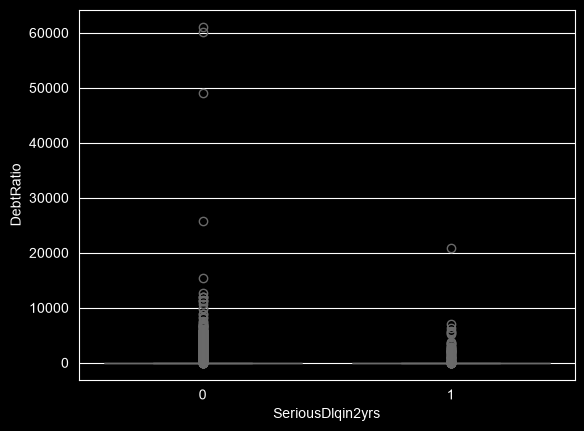

In [23]:
masque = train_credit_data["MissingIncomeFlag"] == 1
train_credit_data.loc[masque,"DebtRatio"] = train_credit_data.loc[masque,"DebtRatio"]/train_credit_data.loc[masque,"MonthlyIncome"]

train_credit_data.loc[masque,"DebtRatio"].describe()
sns.boxplot(x=y_etude, y="DebtRatio", data=train_credit_data)


Même si un certain nombre outliers persiste, il y a clairement une nette différence suite à cette opération. On a également vérifié que les outliers restants ne provenaient plus des clients flaggés comme ayant un revenu manquant, on décide donc de traiter le reste de ces valeurs par un clip au point d'inflexion des quantiles.

In [24]:
print(etude_sauts_quantiles(train_credit_data,"DebtRatio"))
train_credit_data = cap_outliers_quantile(train_credit_data, "DebtRatio", 0.980)

           quantile          diff
0.900      0.748588           NaN
0.910      0.785419      0.036830
0.920      0.831859      0.046441
0.930      0.891518      0.059658
0.940      0.960370      0.068853
0.950      1.060424      0.100054
0.960      1.217602      0.157178
0.970      1.491070      0.273468
0.980      2.464085      0.973015
0.990    250.000000    247.535915
0.995   1436.000000   1186.000000
0.996   1783.000000    347.000000
0.997   2179.872000    396.872000
0.998   2778.248000    598.376000
0.999   3954.912000   1176.664000
1.000  61106.500000  57151.588000
DebtRatio : Plafonné au quantile 0.98 (Valeur max = 2.46)


On décide ici de faire un clipping strict puisque dès le quantile 0.990, des valeurs aberrantes comme 250 soit 25000% de ratio de dette commencent à apparaître. Ce sont des ratios de dette aberrants et les laisser dans le jeu de données biaiserait beaucoup trop les modèles.

<Axes: xlabel='SeriousDlqin2yrs', ylabel='DebtRatio'>

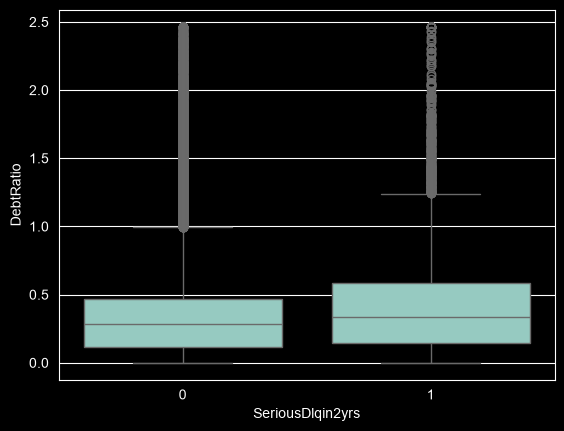

In [25]:
sns.boxplot(x=y_etude, y="DebtRatio", data=train_credit_data)

Le boxplot résultant montre une donnée saine en cohérence avec la réalité du monde financier. Pour les bons payeurs, on a une médiane à environs 25%, celle des mauvais payeurs est plus haute vers 45%. De pus, on voit une nette différence entre les Q3 des deux groupes avec l'un à 100% et l'autre à près de 125%.

## Analyse Multivariée

Ici, le but va être de repérer de potentielles corrélations importantes entre des variables du dataset. On décidera ensuite de soit fusionner, soit supprimer les cas de variables qui font "doublons".

<Axes: >

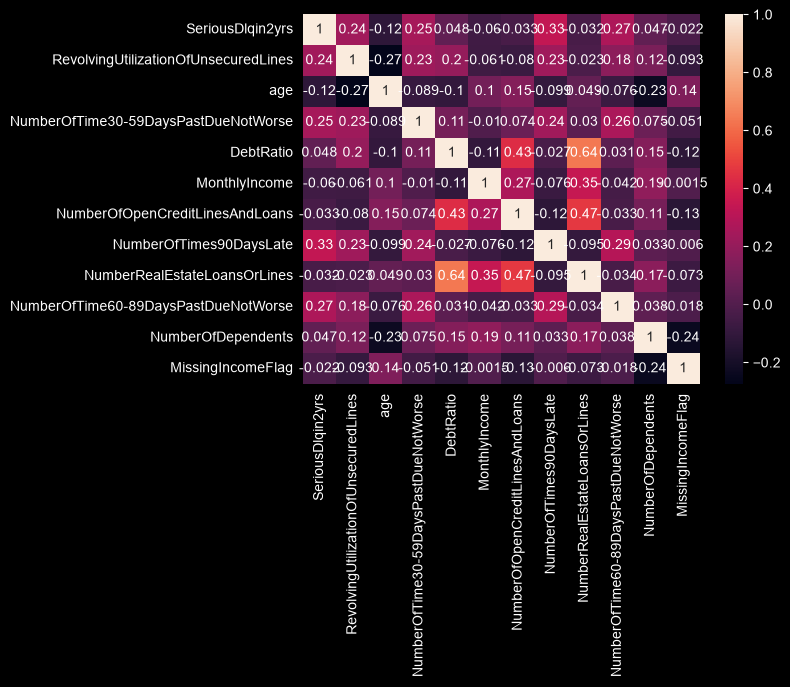

In [26]:
corr = train_credit_data.corr(method="spearman")

sns.heatmap(corr, annot=True)

Cette heatmap est prometteuse quant à la qualité de notre dataset. En effet, on voit plusieurs choses :
- Les variables les plus corrélées avec notre cible sont les variables de retards `NumberOfTimes...` et `RevolvingUtilizationOfUnsecuredLines` ce qui est cohérent avec l'intuition qu'on a de la réalité des choses
- Les variables de retard sont correlées mais pas non plus de façon extrême
- `NumberRealEstateLoansOrLines` et `NumberOfOpenCreditLinesAndLoans` sont corrélées entre elles ainsi qu'avec `DebtRatio`, ce qui, ici encore, est cohérent avec l'intuition que l'on peut avoir.

On a donc des données qui ont l'air saines, en plus de ne pas comporter de correlations trop importantes, on peut donc garder toutes les variables pour l'entraînement des modèles.

# f. Conclusion Partielle

On a donc complété la phase d'analyse exploratoire des données de notre dataset Give Me Some Credit qui servira de base d'entraînement et de test de nos modèles de Credit Scoring. La prochaine étape va être la discussion du train test split puis l'implémentation d'un premier modèle de régression. Nous conclurons ce notebook par l'export de nos données traitées.

In [27]:
dir_processed = "../data/processed/"
path_train_data_processed = dir_processed+"train-credit-data.parquet"
path_val_data_processed = dir_processed+"val-credit-data.parquet"

if not os.path.exists(dir_processed):
    os.mkdir(dir_processed)
train_credit_data.to_parquet(path_train_data_processed)
val_credit_data.to_parquet(path_val_data_processed)